In [1]:
import numpy as np
import bagpipes as pipes
import matplotlib.pyplot as plt

In [2]:
filter_list_splus = ['filters/uJAVA.dat',
                     'filters/F0378.dat',
                     'filters/F0395.dat',
                     'filters/F0410.dat',
                     'filters/F0430.dat',
                     'filters/gSDSS.dat',
                     'filters/F0515.dat',
                     'filters/rSDSS.dat',
                     'filters/F0660.dat',
                     'filters/iSDSS.dat',
                     'filters/F0861.dat',
                     'filters/zSDSS.dat']

In [3]:
exp = {}                          # Tau model star formation history component
exp["age"] = 10.                 # Gyr
exp["tau"] = 2.                  # Gyr
exp["massformed"] = 11.           # log_10(M*/M_solar)
exp["metallicity"] = 0.9         # Z/Z_oldsolar (approx. solar metallicity)

nebular = {}                      # Nebular emission component
nebular["logU"] = -2.             # log_10(ionization parameter)

dust = {}                         # Dust component
dust["type"] = "Salim"         # Define the shape of the attenuation curve
dust["Av"] = 0.5                  # magnitudes
dust["eta"] = 1.                   # Multiplicative factor on Av for stars in birth clouds
dust["delta"] = 0.         # Deviation from Calzetti slope ("Salim" type only)
dust["B"] = 0.             # 2175A bump strength ("Salim" type only)

#Nebular emission for cold and diffuse dust:
dust["qpah"] = 0.5                # PAH mass fraction -  dust emission
dust["umin"] = 1.                # Lower limit of starlight intensity distribution
dust["gamma"] = 0.01                # Fraction of dust exposed to starlight intensities above umin

model_components = {}                   # The model components dictionary
model_components["redshift"] = 0.3      # Observed redshift
model_components["exponential"] = exp
model_components["t_bc"] = 0.01         # Lifetime of birth clouds (Gyr)
model_components["veldisp"] = 100.      # km/s
model_components["nebular"] = nebular
model_components["dust"] = dust

model_list = []

modelBase = pipes.model_galaxy(model_components, filt_list=filter_list_splus, spec_wavs=np.arange(1000., 10000., 5.))
model_list.append(modelBase)
pltTitles = ['Base Av=0.5']

In [4]:
def SetDust(type = "Salim", av = 0.5, eta = 1, qpah = 0.5, umin = 1., gamma = 0.01, delta = 0.0, B = 0.0):

    dust["type"] = type         # Define the shape of the attenuation curve
    dust["Av"] = av                  # magnitudes
    dust["eta"] = eta                   # Multiplicative factor on Av for stars in birth clouds
    dust["delta"] = delta         # Deviation from Calzetti slope ("Salim" type only)
    dust["B"] = B             # 2175A bump strength ("Salim" type only)
    dust["qpah"] = qpah                # PAH mass fraction -  dust emission
    dust["umin"] = umin                # Lower limit of starlight intensity distribution
    dust["gamma"] = gamma                # Fraction of dust exposed to starlight intensities above umin

In [5]:
SetDust(av=1)

modelAv1 = pipes.model_galaxy(model_components, filt_list=filter_list_splus, spec_wavs=np.arange(1000., 10000., 5.))
model_list.append(modelAv1)
pltTitles.append('Av=1')

SetDust(av=2)

modelAv2 = pipes.model_galaxy(model_components, filt_list=filter_list_splus, spec_wavs=np.arange(1000., 10000., 5.))
model_list.append(modelAv2)
pltTitles.append('Av=2')

In [6]:
SetDust()
modelBase = pipes.model_galaxy(model_components, filt_list=filter_list_splus, spec_wavs=np.arange(1000., 10000., 5.))
model_list.append(modelBase)
pltTitles.append('Base Eta=1')

SetDust(eta=2)

modelEta1 = pipes.model_galaxy(model_components, filt_list=filter_list_splus, spec_wavs=np.arange(1000., 10000., 5.))
model_list.append(modelEta1)
pltTitles.append('Eta=2')

SetDust(eta=3)

modelEta2 = pipes.model_galaxy(model_components, filt_list=filter_list_splus, spec_wavs=np.arange(1000., 10000., 5.))
model_list.append(modelEta2)
pltTitles.append('Eta=3')

In [7]:
SetDust(qpah=4, umin=1.1, gamma=0.007)

modelQpah2 = pipes.model_galaxy(model_components, filt_list=filter_list_splus, spec_wavs=np.arange(1000., 10000., 5.))
model_list.append(modelQpah2)
pltTitles.append('Emission from NGC 3521')

SetDust(qpah=3.2, umin=7, gamma=0.14)

modelQpah1 = pipes.model_galaxy(model_components, filt_list=filter_list_splus, spec_wavs=np.arange(1000., 10000., 5.))
model_list.append(modelQpah1)
pltTitles.append('Emission from Mark 33')

SetDust(qpah=0.5, umin=2.3, gamma=0.012)

modelBase = pipes.model_galaxy(model_components, filt_list=filter_list_splus, spec_wavs=np.arange(1000., 10000., 5.))
model_list.append(modelBase)
pltTitles.append('Emission from IC2574')

In [8]:
SetDust()
modelBase = pipes.model_galaxy(model_components, filt_list=filter_list_splus, spec_wavs=np.arange(1000., 10000., 5.))
model_list.append(modelBase)
pltTitles.append('Base delta=0 and B=0')

SetDust(delta=1, B=1)

modelN1 = pipes.model_galaxy(model_components, filt_list=filter_list_splus, spec_wavs=np.arange(1000., 10000., 5.))
model_list.append(modelN1)
pltTitles.append('Base delta=1 and B=1')

SetDust(delta=5, B=5)

modelN2 = pipes.model_galaxy(model_components, filt_list=filter_list_splus, spec_wavs=np.arange(1000., 10000., 5.))
model_list.append(modelN2)
pltTitles.append('Base delta=5 and B=5')

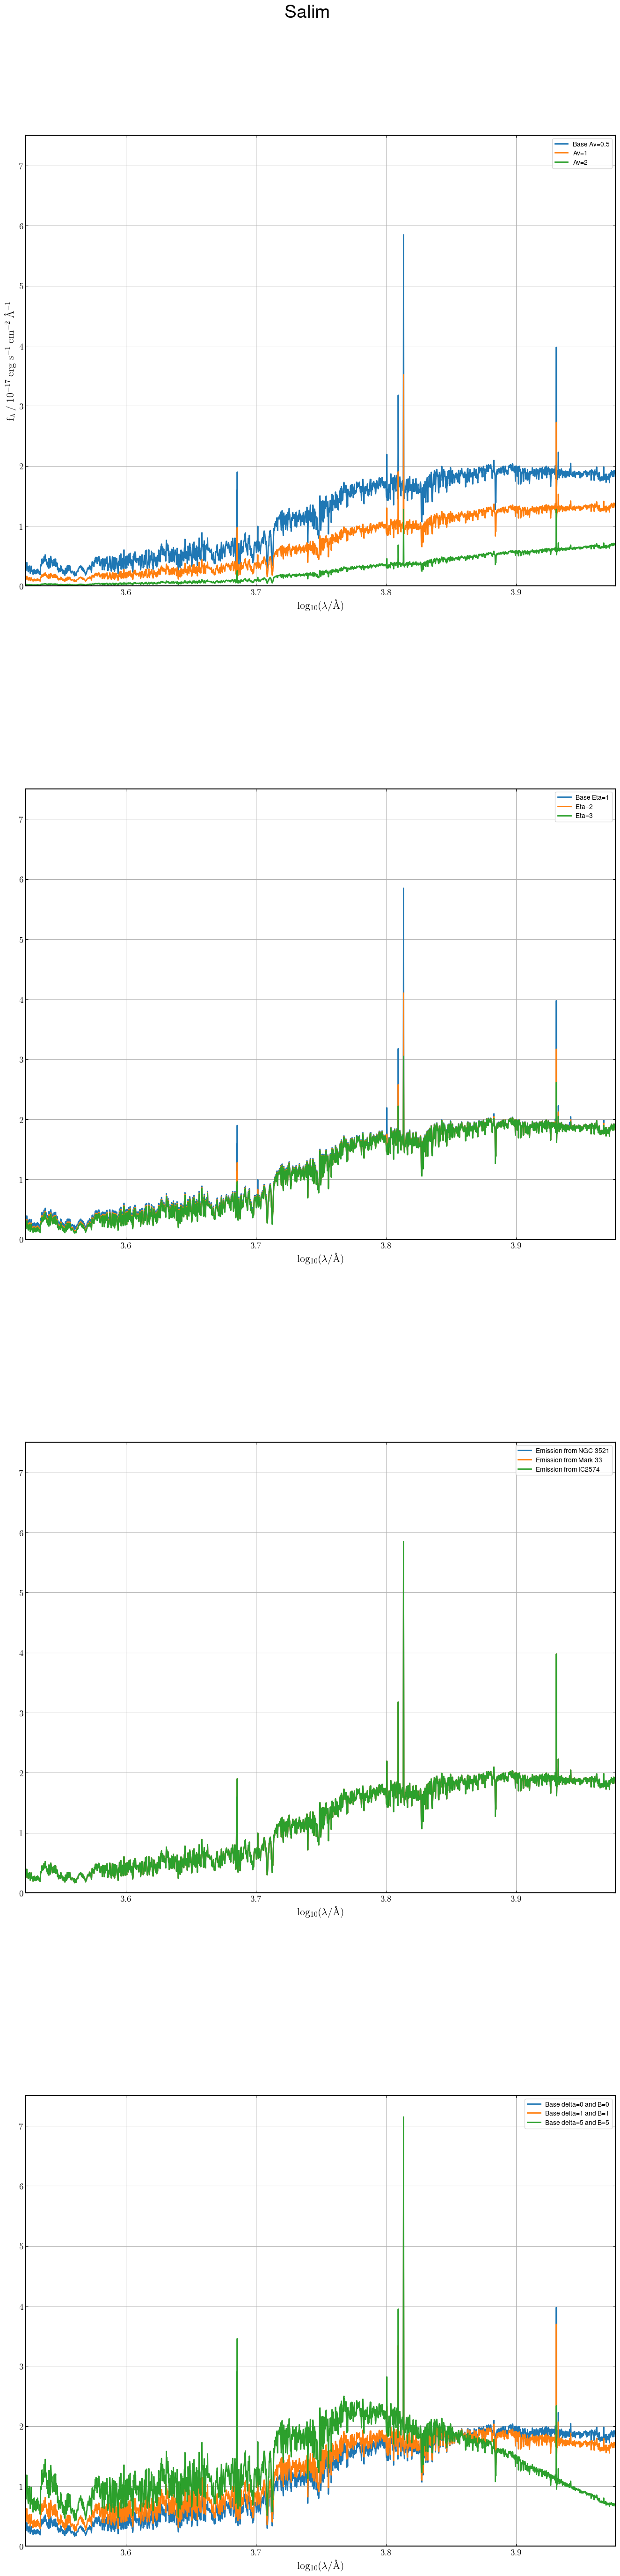

In [9]:
ax_list = []
counter = 0

for mdl in model_list:
    fig, axes = mdl.plot(show=False)

    if counter % 3 == 0:
        ax_list.append([])

    ax_list[int(counter / 3)].append(axes[1])
    plt.close(fig)
    counter += 1

n = int(len(ax_list))
rows = 4

fig_grid, axes_grid = plt.subplots(rows, 1, figsize=(14, 14 * rows), sharey=True)
axes_grid = axes_grid.flatten()
i = 0

for idx, (ax_target, ax_sources) in enumerate(zip(axes_grid, ax_list)):
    
    for ax_source in ax_sources:
        # Copia o conteúdo do ax_source para ax_target
        for line in ax_source.get_lines():
            ax_target.plot(line.get_xdata(), line.get_ydata(), linestyle=line.get_linestyle(), marker=line.get_marker(), label=pltTitles[i])
            i += 1

    # Copia título, labels, etc.
    ax_target.set_xlabel(ax_source.get_xlabel(), fontsize=16)
    # Só mostra o ylabel nos gráficos mais à esquerda
    if idx % rows == 0:
        ax_target.set_ylabel(ax_source.get_ylabel(), fontsize=16)
    else:
        ax_target.set_ylabel("")
    ax_target.set_xlim(ax_source.get_xlim())
    ax_target.set_ylim(ax_source.get_ylim())
    ax_target.legend()
    ax_target.grid(True)

for ax in axes_grid[n:]:
    ax.axis('off')

fig_grid.suptitle("Salim", fontsize=28, fontweight='bold', y=1.04)
plt.subplots_adjust(left=0.07, right=0.97, top=0.99, bottom=0.07, wspace=0.35, hspace=0.45)

plt.savefig("./results/Salim.png")

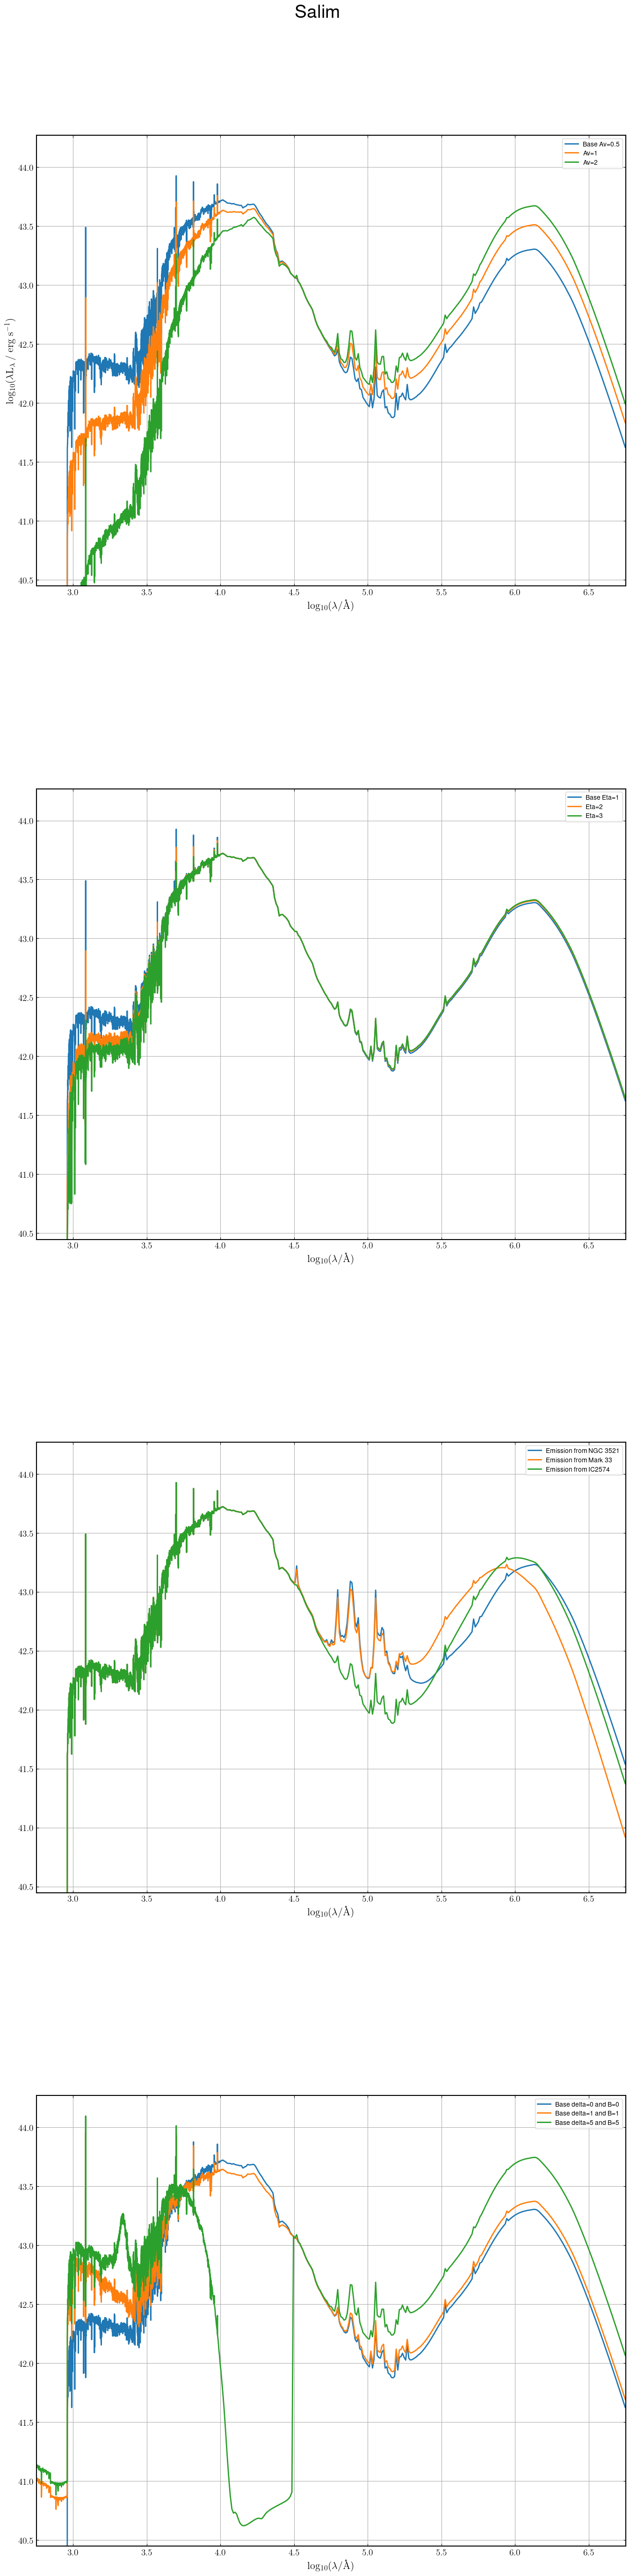

In [10]:
ax_list = []
counter = 0

for mdl in model_list:
    fig, axes = mdl.plot_full_spectrum(show=False)

    if counter % 3 == 0:
        ax_list.append([])

    ax_list[int(counter / 3)].append(axes)
    plt.close(fig)
    counter += 1

n = int(len(ax_list))
rows = 4

fig_grid, axes_grid = plt.subplots(rows, 1, figsize=(14, 14 * rows), sharey=True)
axes_grid = axes_grid.flatten()
i = 0

for idx, (ax_target, ax_sources) in enumerate(zip(axes_grid, ax_list)):
    
    for ax_source in ax_sources:
        # Copia o conteúdo do ax_source para ax_target
        for line in ax_source.get_lines():
            ax_target.plot(line.get_xdata(), line.get_ydata(), linestyle=line.get_linestyle(), marker=line.get_marker(), label=pltTitles[i])
            i += 1

    # Copia título, labels, etc.
    ax_target.set_xlabel(ax_source.get_xlabel(), fontsize=16)
    # Só mostra o ylabel nos gráficos mais à esquerda
    if idx % rows == 0:
        ax_target.set_ylabel(ax_source.get_ylabel(), fontsize=16)
    else:
        ax_target.set_ylabel("")
    ax_target.set_xlim(ax_source.get_xlim())
    ax_target.set_ylim(ax_source.get_ylim())
    ax_target.legend()
    ax_target.grid(True)

for ax in axes_grid[n:]:
    ax.axis('off')

fig_grid.suptitle("Salim", fontsize=28, fontweight='bold', y=1.04)
plt.subplots_adjust(left=0.07, right=0.97, top=0.99, bottom=0.07, wspace=0.35, hspace=0.45)

plt.savefig("./results/SalimFull.png")